In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit
from tqdm import tqdm
from scipy.stats import beta

import bayesflow as bf
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.trainers import Trainer

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


- Create a true population with infections, get a biased sample from it
- The biased sample represents the data we would get from an actual study
- From the true population, we pretend to know only the distribution of the covariates (and the infectiousness related with these, in a real application, we would also estimate these)
- Hence, we can create an approximation of the true population by stratified sampling from the biased sample

In [3]:
# 1. Sampling from priors
def get_realistic_priors():
    """With these priors, the uncorrected prevalence will generally be too low compared to the true population prevalence. This is because the sampling mechanism systematically underrepresents high-risk groups and overrepresents low-risk groups.
    The corrected prevalence using inverse probability weighting should compensate for this by giving more weight to the underrepresented high-risk groups, resulting in a higher and more accurate estimate of the true prevalence."""
    # Infection model priors
    infection_prior_means = {
        'intercept': -2.0,      # Base infection rate around 12% (logit-1(-2.0) ≈ 0.12)
        'age': 0.015,           # Moderate increase in infection risk with age
        'gender_female': -0.25, # Slightly lower risk for females
        'region_north': 0.4,    # Higher infection rate in north region
        'region_south': 0.1,    # Slightly higher in south
        'region_east': -0.1,    # Slightly lower in east
        'region_west': -0.3     # Lower in west
    }

    # Larger standard deviations for more diverse datasets
    infection_prior_stds = {
        'intercept': 0.8,       # Large uncertainty in base rate (prevalence from ~5% to ~25%)
        'age': 0.01,            # Moderate variability in age effect
        'gender_female': 0.4,   # High uncertainty in gender effect
        'region_north': 0.5,    # High uncertainty in regional effects
        'region_south': 0.5,
        'region_east': 0.5,
        'region_west': 0.5
    }

    # Inclusion model priors (sampling bias)
    inclusion_prior_means = {
        'intercept': -0.8,      # Base inclusion rate around 31% (logit-1(-0.8) ≈ 0.31)
        'age': -0.02,           # Decreased participation with age
        'gender_female': 0.5,   # Women more likely to participate
        'region_north': -0.4,   # Regional differences in participation
        'region_south': -0.2,
        'region_east': 0.3,
        'region_west': 0.5      # Higher participation in west
    }

    # Larger standard deviations for more diverse datasets
    inclusion_prior_stds = {
        'intercept': 0.6,       # Large uncertainty in base inclusion rate
        'age': 0.008,           # Moderate variability in age effect
        'gender_female': 0.35,  # High uncertainty in gender effect
        'region_north': 0.45,   # High uncertainty in regional effects
        'region_south': 0.45,
        'region_east': 0.45,
        'region_west': 0.45
    }

    return (infection_prior_means, infection_prior_stds,
            inclusion_prior_means, inclusion_prior_stds)

def sample_logit_models_from_priors(
    infection_covariates, inclusion_covariates,
    infection_prior_means=None, infection_prior_stds=None,
    inclusion_prior_means=None, inclusion_prior_stds=None,
    default_mean=0.0, default_std=1.0, seed=None
):
    if seed is not None:
        np.random.seed(seed)

    def sample_params(covariates, means, stds):
        means = means or {}
        stds = stds or {}
        return {
            cov: np.random.normal(loc=means.get(cov, default_mean), scale=stds.get(cov, default_std))
            for cov in covariates
        }

    infection_params = sample_params(infection_covariates, infection_prior_means, infection_prior_stds)
    inclusion_params = sample_params(inclusion_covariates, inclusion_prior_means, inclusion_prior_stds)

    return infection_params, inclusion_params

# 2. Simulate a population
def simulate_population(
    n,
    infection_logit_params, inclusion_logit_params,
    oversample_factor=100,  # Simulate more to ensure enough inclusion diversity
    biased_sample=True,  # to get unbiased prevalence
):
    N_pool = n * oversample_factor
    age_params = (50, 15)
    gender_probs = {'male': 0.5, 'female': 0.5}
    region_probs = {'north': 0.25, 'south': 0.25, 'east': 0.25, 'west': 0.25}

    # Step 1: simulate covariates
    age = np.random.normal(loc=age_params[0], scale=age_params[1], size=N_pool)
    gender = np.random.choice(list(gender_probs.keys()), size=N_pool, p=list(gender_probs.values()))
    region = np.random.choice(list(region_probs.keys()), size=N_pool, p=list(region_probs.values()))
    df = pd.DataFrame({'age': age, 'gender': gender, 'region': region})
    df_encoded = pd.get_dummies(df, drop_first=False)

    if not biased_sample:
        # Randomly assign infection status
        rand_prev = np.random.uniform(0.1, 0.6)
        df['infection'] = np.random.binomial(1, rand_prev, size=N_pool)

    # Step 2: compute inclusion probs
    inclusion_logit = np.full(N_pool, inclusion_logit_params.get('intercept', 0.0))
    for k, v in inclusion_logit_params.items():
        if k == 'intercept':
            continue
        elif k == 'age':
            inclusion_logit += v * df['age']
        elif k in df_encoded.columns:
            inclusion_logit += v * df_encoded[k]
    inclusion_prob = expit(inclusion_logit)
    df['inclusion_prob'] = inclusion_prob

    # Step 3: sample directly from inclusion distribution
    weights = inclusion_prob / inclusion_prob.sum()
    sampled_idx = np.random.choice(N_pool, size=n, replace=True, p=weights)
    df_sampled = df.iloc[sampled_idx].copy()

    # Step 4: compute infection for sampled individuals
    if not biased_sample:
        # Randomly assign infection status
        return df_sampled
    else:
        # Compute infection logit
        infection_logit = np.full(n, infection_logit_params.get('intercept', 0.0))
        df_encoded = pd.get_dummies(df_sampled[['age', 'gender', 'region']], drop_first=False)
        for k, v in infection_logit_params.items():
            if k == 'intercept':
                continue
            elif k == 'age':
                infection_logit += v * df_sampled['age']
            elif k in df_encoded.columns:
                infection_logit += v * df_encoded[k]
        df_sampled['infection'] = np.random.binomial(1, expit(infection_logit))
    return df_sampled

# 3. Estimate prevalence
def estimate_prevalence(sampled_df):
    uncorrected = sampled_df['infection'].mean()
    weights = 1 / sampled_df['inclusion_prob']
    corrected = np.average(sampled_df['infection'], weights=weights)
    return uncorrected, corrected

infection_prior_means, infection_prior_stds, inclusion_prior_means, inclusion_prior_stds = get_realistic_priors()
# 4. Run simulation study
def run_simulation_study(
    n_runs=500, sample_target=1000, biased_sample=True
):
    infection_covs = ['intercept', 'age', 'gender_female', 'region_north']
    inclusion_covs = ['intercept', 'age', 'gender_female', 'region_west']
    uncorrected_prevalences = []
    corrected_prevalences = []

    for i in tqdm(range(n_runs)):
        infection_params, inclusion_params = sample_logit_models_from_priors(
            infection_covariates=infection_covs,
            inclusion_covariates=inclusion_covs,
            infection_prior_means=infection_prior_means,
            infection_prior_stds=infection_prior_stds,
            inclusion_prior_means=inclusion_prior_means,
            inclusion_prior_stds=inclusion_prior_stds,
            seed=i
        )
        df_sampled = simulate_population(
            n=sample_target,
            infection_logit_params=infection_params,
            inclusion_logit_params=inclusion_params,
            biased_sample=biased_sample
        )

        uncor, cor = estimate_prevalence(df_sampled)

        uncorrected_prevalences.append(uncor)
        corrected_prevalences.append(cor)

    return uncorrected_prevalences, corrected_prevalences

# Run and plot
uncor_prev, cor_prev = run_simulation_study()

100%|██████████| 500/500 [00:17<00:00, 27.83it/s]


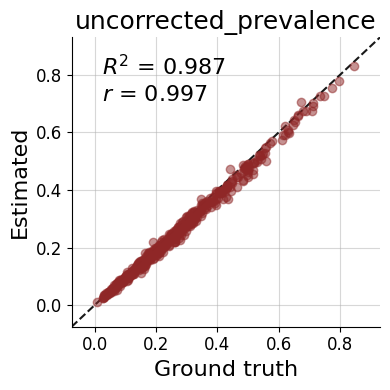

In [4]:
bf.diagnostics.plot_recovery(np.array(uncor_prev)[:, np.newaxis, np.newaxis],
                             np.array(cor_prev)[:, np.newaxis],
                             param_names=['uncorrected_prevalence']);

In [5]:
column_names = ['age', 'infection', 'gender_female', 'region_north', 'region_south', 'region_west']

In [6]:
def convert_to_nn_input(new_population: pd.DataFrame) -> np.ndarray:
    new_population_nn = pd.get_dummies(new_population, drop_first=False)
    # add zero colums if missing
    for col in column_names:
        if col not in new_population_nn.columns:
            new_population_nn[col] = 0
    new_population_nn = new_population_nn[column_names]
    new_population_nn = new_population_nn.values * 1
    new_population_nn[:, 0] = new_population_nn[:, 0] / 70  # normalize age
    return new_population_nn

In [7]:
param_names = ['prevalence']

In [8]:
infection_covs = ['intercept', 'age', 'gender_female', 'region_north']
inclusion_covs = ['intercept', 'age', 'gender_female', 'region_west']

def generative_model(batch_size, pop_size=100):
    out_dict = {
        'sim_data': np.zeros((batch_size, pop_size, 6), dtype=np.float32),
        'prior_draws': np.zeros((batch_size, len(param_names)), dtype=np.float32)
    }
    for b in range(batch_size):
        infection_params, inclusion_params = sample_logit_models_from_priors(
            infection_covariates=infection_covs,
            inclusion_covariates=inclusion_covs,
            infection_prior_means=infection_prior_means,
            infection_prior_stds=infection_prior_stds,
            inclusion_prior_means=inclusion_prior_means,
            inclusion_prior_stds=inclusion_prior_stds
        )

        # generate a new population
        new_population = simulate_population(
            n=pop_size,
            infection_logit_params=infection_params,
            inclusion_logit_params=inclusion_params,
            biased_sample=True
        )
        uncor, cor = estimate_prevalence(new_population)

        # save the data and parameters
        out_dict['sim_data'][b] = convert_to_nn_input(new_population)
        out_dict['prior_draws'][b] = cor
    return out_dict

In [9]:
valid_data = generative_model(1000)

In [11]:
summary_net = DeepSet(summary_dim=5)

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=5,
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [12]:
def configurator(forward_dict: dict) -> dict:
    # Extract data
    out_dict = {
        'summary_conditions': forward_dict["sim_data"].astype(np.float32)
    }

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        #params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

In [13]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    #checkpoint_path='amortizer_prevalence',
)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [ ]:
if trainer.checkpoint_path is None:
    history = trainer.train_online(
        epochs=10,
        batch_size=32,
        iterations_per_epoch=100,
        early_stopping=True,
        validation_sims=valid_data
    )
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

Training epoch 1:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [ ]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=100)
#posterior_samples = posterior_samples * prior_std + prior_mean

In [ ]:
bf.diagnostics.plot_sbc_ecdf(posterior_samples, valid_data['prior_draws'], difference=True, param_names=param_names)
bf.diagnostics.plot_recovery(posterior_samples, valid_data['prior_draws'], param_names=param_names)
bf.diagnostics.plot_z_score_contraction(posterior_samples, valid_data['prior_draws'], param_names=param_names);

In [ ]:
# Define the true population
def generate_true_population(size: int, seed: int = None) -> pd.DataFrame:
    # generator
    rnd = np.random.default_rng(seed=seed)
    
    # Distribution of gender, age groups, and urban/rural location
    gender = rnd.choice(['male', 'female'], size=size)
    age_group = rnd.choice(['0-18', '19-35', '36-60', '61+'], size=size, p=[0.2, 0.3, 0.3, 0.2])
    location = rnd.choice(['urban', 'rural'], size=size, p=[0.6, 0.4]) 

    # Baseline infectiousness and relative age-dependent infectiousness
    if seed is not None:  # fixed infection probability for reproducibility
        infection_prob = 0.05
    else:
        infection_prob = rnd.beta(1, 2)  # reflects a near uniform distribution of infectiousness
    baseline_infectiousness = np.log(infection_prob / (1 - infection_prob))
    relative_infectiousness = {'0-18': 1., '19-35': np.log(1.0), '36-60':np.log(1.5), '61+': np.log(2.0)}
    urban_infectiousness_multiplier = 1.3  # 30% higher risk in urban areas
    
    # Adjust infectiousness based on location (higher in urban areas)
    # Calculate infections based on age group and location
    # Calculate log-odds of infection based on age and location
    log_odds = (baseline_infectiousness + 
                np.array([relative_infectiousness[age] for age in age_group]) +
                urban_infectiousness_multiplier * np.array([1. if loc == 'urban' else 0. for loc in location]))
    infection_prob = 1. / (1. + np.exp(-log_odds))
    
    # Generate infections based on calculated probabilities
    infections = rnd.uniform(size=size) < infection_prob
    
    # Create a DataFrame for the population
    return pd.DataFrame({
        'gender': gender,
        'age_group': age_group,
        'location': location,
        'infected': infections
    })

true_population = generate_true_population(size=1000, seed=42)

In [ ]:
# generate a biased sample from a full population
def sample_population(
        full_population: pd.DataFrame,
        sample_size: int,
        urban_overrepresented: bool = False,
        seed: int = None
) -> pd.DataFrame:
    if urban_overrepresented:
        # Over-represent urban individuals
        urban_sample = full_population[full_population['location'] == 'urban'].sample(frac=0.9, replace=False, random_state=seed)
        rural_sample = full_population[full_population['location'] == 'rural'].sample(frac=0.1, replace=False, random_state=seed)
        new_sample = pd.concat([urban_sample, rural_sample]).sample(n=sample_size, replace=False, random_state=seed)
    else:
        # Random sample
        new_sample = full_population.sample(n=sample_size, replace=False, random_state=seed)
    return new_sample

true_biased_sample = sample_population(true_population, sample_size=400, urban_overrepresented=True, seed=42)
true_random_sample = sample_population(true_population, sample_size=400, urban_overrepresented=False, seed=42)

In [ ]:
# Prepare counts for true and biased samples
true_counts = true_population[['location', 'infected']].value_counts()
biased_counts = true_biased_sample[['location', 'infected']].value_counts()
random_counts = true_random_sample[['location', 'infected']].value_counts()

# Plot setup with bars and percentages
fig, ax = plt.subplots(ncols=3, figsize=(5, 3), sharey=True, sharex=True, tight_layout=True)
# remove grid


# Bar width and colors
bar_width = 0.35
pop_type = ['Urban', 'Rural']
colors = ['#e66101', '#fdb863', '#5e3c99', '#b2abd2']

for i, counts in enumerate([true_counts, random_counts, biased_counts]):
    ax[i].grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

    # Calculate percentages for true and biased counts
    percents = counts / counts.sum()

    # True population bars and percentages
    urban_total = counts[('urban',)].sum()
    urban_infected = counts[('urban', True)]
    rural_total = counts[('rural',)].sum()
    rural_infected = counts[('rural', True)]
    total_infected = urban_infected + rural_infected

    ax[i].bar(pop_type[0], urban_total, width=bar_width, color=colors[0], alpha=1)
    ax[i].bar(pop_type[0], urban_total - urban_infected, width=bar_width, color=colors[1], alpha=1)
    ax[i].bar(pop_type[1], rural_total, width=bar_width, color=colors[2], alpha=1)
    ax[i].bar(pop_type[1], rural_total - rural_infected, width=bar_width, color=colors[3], alpha=1)

    ax[i].text(0, urban_total+20, f"{urban_infected / counts.sum():.1%}", ha='center', va='center', color=colors[0])
    ax[i].text(1, rural_total+20, f"{rural_infected / counts.sum():.1%}", ha='center', va='center', color=colors[2])

    ax[i].set_xlabel("Region")
    ax[i].set_ylabel("Population Size")

# Titles and labels
ax[0].set_ylim(0, 750)
ax[0].set_title("True Population")
ax[2].set_title("Biased Sample")
ax[1].set_title("Random Sample")

ax[0].set_xlim(-0.5, 1.5)
fig.legend(["Infected - Urban", "Not Infected - Urban", "Infected - Rural", "Not Infected - Rural"],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.15))
plt.show()

In [ ]:
# calculate the prevalence of the population
def calculate_prevalence(sample: pd.DataFrame) -> float:
    return sample['infected'].mean()


def calculate_weights(sample: pd.DataFrame, full_population: pd.DataFrame, covariates: list) -> np.ndarray:
    # Calculate population distribution for all covariate combinations
    full_population_distribution = full_population.groupby(covariates).size() / len(full_population)
    
    # Calculate sample distribution for all covariate combinations
    sample_distribution = sample.groupby(covariates).size() / len(sample)
    
    # Initialize a column for weights
    weights = pd.Series(np.zeros(len(sample)), index=sample.index)
    
    # Iterate over all unique covariate combinations
    for covariate_values, full_population_ratio in full_population_distribution.items():
        sample_ratio = sample_distribution.get(covariate_values, 0)
        
        # Calculate weight
        weight = full_population_ratio / sample_ratio if sample_ratio > 0 else 0
        
        # Assign weight to the corresponding rows in the sample
        condition = (sample[list(covariates)] == pd.Series(covariate_values, index=covariates)).all(axis=1)
        weights.loc[condition] = weight

    return weights
    

def calculate_weighted_prevalence(sample: pd.DataFrame, full_population: pd.DataFrame) -> float:
    # Calculate weights
    sample['weight'] =  calculate_weights(sample, full_population, covariates=['age_group', 'gender', 'location'])

    # Calculate weighted prevalence
    return np.average(sample['infected'], weights=sample['weight'])


weighted_prevalence = calculate_weighted_prevalence(true_biased_sample, true_population)
_ = calculate_weighted_prevalence(true_random_sample, true_population)

In [ ]:
# generate a full population from a biased sample
def generate_population_from_sample(biased_sample: pd.DataFrame, seed: int = None) -> pd.DataFrame:
    # Generate a population DataFrame based on the sample
    # Calculate weights
    biased_sample['weight'] = calculate_weights(biased_sample, true_population, covariates=['age_group', 'gender', 'location'])

    # Generate a population DataFrame based on the sample
    population = biased_sample.sample(
        n=true_population.shape[0],
        replace=True,
        weights=biased_sample['weight'],
        random_state=seed
    )
    return population

In [ ]:
# visualize the results
def visualize_results(full_population: pd.DataFrame, 
                      random_sample: pd.DataFrame, biased_sample: pd.DataFrame, 
                      weighted_prevalence: float):
    # Calculate prevalences
    true_prevalence = calculate_prevalence(full_population)
    random_prevalence = calculate_prevalence(random_sample)
    biased_prevalence = calculate_prevalence(biased_sample)

    # Create visualization
    labels = ['True Prevalence', 'Random Sample', 'Biased Sample', 'Weighted Biased Sample']
    prevalences = [true_prevalence, random_prevalence, biased_prevalence, weighted_prevalence]

    plt.figure(figsize=(8, 4))
    plt.bar(labels, prevalences, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    plt.ylabel('Prevalence')
    plt.ylim(0, max(prevalences) + 0.05)
    plt.title('Prevalence Comparison')
    plt.show()
    
visualize_results(true_population, true_random_sample, true_biased_sample, weighted_prevalence)

In [ ]:
# repeated samples from the true population -> estimate bias for different sampling schemes
n_rounds = 100
sampled_prevalence = np.zeros(n_rounds)
sampled_prevalence_biased = np.zeros(n_rounds)
sampled_prevalence_weighted = np.zeros(n_rounds)
for i in range(n_rounds):
    _random_sample = sample_population(true_population, sample_size=200, urban_overrepresented=False)
    _biased_sample = sample_population(true_population, sample_size=200, urban_overrepresented=True)
    
    sampled_prevalence[i] = calculate_prevalence(_random_sample)
    sampled_prevalence_biased[i] = calculate_prevalence(_biased_sample)
    sampled_prevalence_weighted[i] = calculate_weighted_prevalence(_biased_sample, true_population)
    
plt.figure(figsize=(7, 4))
labels = ['Random Sample', 'Biased Sample', 'Weighted Sample']
for i, p in enumerate([sampled_prevalence, sampled_prevalence_biased, sampled_prevalence_weighted]):
    plt.errorbar(labels[i], [np.median(p)], [np.std(p)], fmt='o')
plt.axhline(calculate_prevalence(true_population), color='b', linestyle='--', label='True Prevalence')
plt.ylabel('Prevalence')
plt.title('Prevalence Comparison')
plt.legend()
plt.show()

# Analytical Posterior

uniform prior on prevalence $\theta \sim U(0, 1)$
$$
P(\theta \mid X) = Beta(1+k, 1+N-k)
$$

The MAP estimate is the same as the point estimate
$$
MAP = \frac{(1+k)-1}{(1+k)+(1+N-k)-2} = \frac{k}{N}
$$

We can correct for sampling bias by using the weighted counts.

In [ ]:
def posterior_stats(df, alpha_prior=1, beta_prior=1, weighted=False):
    """
    Calculate the posterior median and standard deviation for a Beta distribution
    using a DataFrame with weights and infection status.
    
    Parameters:
    - df: pandas DataFrame containing infection status and weights
    - alpha_prior: prior parameter for the Beta distribution (default=1)
    - beta_prior: prior parameter for the Beta distribution (default=1)
    - weighted: boolean flag to indicate whether to use weighted counts (default=False)
    
    Returns:
    - median: posterior median
    - std_dev: posterior standard deviation
    """
    if weighted and 'weight' in df.columns:
        # Sum of weights for infected individuals
        weighted_k = df.loc[df['infected'] == 1, 'weight'].sum()
    
        # Sum of weights for non-infected individuals
        weighted_Nk = df.loc[df['infected'] == 0, 'weight'].sum()
    else:
        # Number of infected individuals
        k = df['infected'].sum()
    
        # Number of non-infected individuals
        Nk = len(df) - k
    
        # Parameters of the Beta distribution (posterior) with weighted counts
        weighted_k = k
        weighted_Nk = Nk

    # Parameters of the Beta distribution (posterior) with weighted counts
    alpha_post = alpha_prior + weighted_k
    beta_post = beta_prior + weighted_Nk
    
    # Create the Beta distribution object
    posterior = beta(alpha_post, beta_post)
    return posterior

In [ ]:
def calculate_analytical_prevalence(sample: pd.DataFrame, full_population: pd.DataFrame) -> float:
    # Calculate weights
    sample['weight'] =  calculate_weights(sample, full_population, covariates=['age_group', 'gender', 'location'])
    # Calculate the posterior distribution
    analytical_post = posterior_stats(df=sample, weighted=True)
    return analytical_post.median()

In [ ]:
fig, ax = plt.subplots(1, 1, sharey=True, tight_layout=True, figsize=(6, 4))
labels = ['True Posterior', 'Random Sample', 'Biased Sample', 'Weighted Sample']
for i, p in enumerate([true_population, true_random_sample, true_biased_sample, true_biased_sample]):
    if i == 3:
        analytical_posterior = posterior_stats(df=p, weighted=True)
    else:
        analytical_posterior = posterior_stats(df=p, weighted=False)
    ax.errorbar(labels[i], [analytical_posterior.median()], [2*analytical_posterior.std()], fmt='o', 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][i])
ax.axhline(calculate_prevalence(true_population), color='b', linestyle='--', label='True Prevalence')
ax.set_ylabel('Prevalence')
ax.set_title('Prevalence Posterior')
ax.legend()
plt.show()

In [ ]:
# sample from analytical posterior
analytical_posterior = posterior_stats(df=true_biased_sample, weighted=True)
prior_draws = np.random.beta(1, 1, size=1000)  # uniform prior
posterior_samples = analytical_posterior.rvs(1000)
true_prevalence = calculate_prevalence(true_population)

param_names = ['prevalence']
fig = bf.diagnostics.plot_posterior_2d(
    posterior_draws=posterior_samples[:, np.newaxis],
    prior_draws=prior_draws,
    param_names=param_names
)
# add the true parameters
ax = fig.get_axes()
j = 0
for i, a in enumerate(ax):
    # plot only on the diagonal
    if i == i // len(param_names) * (len(param_names)+1):
        a.axvline(calculate_prevalence(true_population), color='b', label='True')
        a.axvline(calculate_weighted_prevalence(true_biased_sample, true_population), color='y', label='Weighted')
        a.axvline(calculate_prevalence(true_biased_sample), color='r', label='Biased')
        a.legend(loc='upper right', bbox_to_anchor=(1.5, 1))
        j += 1
plt.show()

## Prevalence Estimation with NPE

In [ ]:
import bayesflow as bf
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.trainers import Trainer

In [ ]:
param_names = ['prevalence']
param_names

In [ ]:
def convert_to_nn_input(df: pd.DataFrame) -> np.ndarray:
    df_temp = df.copy()
    # convert to neural network input
    if 'weight' in df_temp.columns:
        df_temp.drop(columns=['weight'], inplace=True)
    df_temp = pd.get_dummies(df_temp, columns=['gender', 'age_group', 'location'], drop_first=True)
    # convert true/false into 0/1
    df_temp = df_temp.astype(int)
    return df_temp[['infected', 'gender_male', 'age_group_19-35', 'age_group_36-60', 'age_group_61+', 'location_urban']].values

In [ ]:
def stratified_sampling(param_batch, data, batch_size, seed=None):
    rnd = np.random.default_rng(seed=seed)
    min_val, max_val = 0, 1
    
    # Define the number of bins (equal to the batch size)
    bins = np.linspace(min_val, max_val, batch_size+1)
    
    sampled_data = np.zeros((batch_size, data.shape[1], data.shape[2]), dtype=np.float32)
    sampled_prior_draws = np.zeros((batch_size, 1), dtype=np.float32)
    
    # Step 4: Stratified sampling from each bin
    for i in range(batch_size):
        # Find indices of param_batch that fall into the current bin
        indices_in_bin = np.where((param_batch >= bins[i]) & (param_batch < bins[i + 1]))[0]
        
        # If there are any samples in this bin, choose one randomly
        if len(indices_in_bin) > 0:
            chosen_index = rnd.choice(indices_in_bin, replace=False)
            sampled_data[i] = data[chosen_index]
            sampled_prior_draws[i] = param_batch[chosen_index]
        else:
            # If no sample is available in the bin, randomly select any index from the whole batch
            chosen_index = rnd.choice(len(param_batch), replace=True)
            sampled_data[i] = data[chosen_index]
            sampled_prior_draws[i] = param_batch[chosen_index]

    return {'sim_data': sampled_data, 'prior_draws': sampled_prior_draws}

def generative_model(
        batch_size: int, 
        sample_size: int = 200,
        urban_overrepresented: bool = True,
        output: str = 'true', 
        seed: bool = False,
        stratified: bool = True,
        max_iterations: int = None,
) -> dict:
    if stratified:
        max_iterations = batch_size*5 if max_iterations is None else max_iterations
    else:
        max_iterations = batch_size
    # generate data and parameters
    data = np.zeros((max_iterations, sample_size, 6), dtype=np.float32)
    if output == 'all':
        param_batch = np.zeros((max_iterations, 4), dtype=np.float32)
    else:
        param_batch = np.zeros((max_iterations, 1), dtype=np.float32)

    for i in range(max_iterations):
        # generate a new full population from the true biased sample (the data we would get from the survey)
        new_population = generate_true_population(size=true_population.shape[0], seed=i if seed is True else None)
        # now draw a new biased sample from the population
        new_biased_sample = sample_population(
            full_population=new_population,
            sample_size=sample_size,
            urban_overrepresented=urban_overrepresented,
            seed=i if seed is True else None
        )
        if output == 'true':
            new_prevalence = calculate_prevalence(sample=new_population)
        elif output == 'weighted':
            new_prevalence = calculate_weighted_prevalence(sample=new_biased_sample, full_population=true_population)
        elif output == 'biased':
            new_prevalence = calculate_prevalence(sample=new_biased_sample)
        elif output == 'analytical':
            new_prevalence = calculate_analytical_prevalence(sample=new_biased_sample, full_population=true_population)
        elif output == 'all':
            new_prevalence = np.array([
                calculate_prevalence(sample=new_population),
                calculate_weighted_prevalence(sample=new_biased_sample, full_population=true_population),
                calculate_analytical_prevalence(sample=new_biased_sample, full_population=true_population),
                calculate_prevalence(sample=new_biased_sample)  
            ])
        else:
            raise ValueError('Output must be one of "true", "weighted", "biased" or "all"')
        
        # save the data and parameters
        param_batch[i] = new_prevalence
        data[i] = convert_to_nn_input(new_biased_sample)
        
    # stratified sampling to get nearly uniform distribution of prior_draws
    if stratified:
        out_dict = stratified_sampling(param_batch, data, batch_size, seed=seed)
        return out_dict
    return {'sim_data': data, 'prior_draws': param_batch}

In [ ]:
summary_net = DeepSet(summary_dim=2)

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=3,
    permutation="learnable"
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [ ]:
np.random.seed(42)
_prior_draws = generative_model(1000)['prior_draws']
prior_mean = _prior_draws.mean(axis=0)
prior_std = _prior_draws.std(axis=0)

In [ ]:
plt.hist(_prior_draws, bins=30, alpha=0.5, label='Prior Draws')
plt.axvline(prior_mean, color='r', label='Prior Mean')
plt.legend()
plt.show()

In [ ]:
def configurator(forward_dict: dict) -> dict:
    # Extract data
    out_dict = {
        'summary_conditions': forward_dict["sim_data"].astype(np.float32)
    }

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    checkpoint_path='amortizer_prevalence',
)

In [ ]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    checkpoint_path='amortizer_prevalence',
)

In [ ]:
%%time
offline_data = generative_model(2500)
valid_data = generative_model(256)
prior_draws = valid_data['prior_draws']

In [ ]:
if trainer.checkpoint_path is None:
    history = trainer.train_offline(
        simulations_dict=offline_data,
        epochs=30,
        batch_size=128,
        early_stopping=True,
        validation_sims=valid_data
    )
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

In [ ]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [ ]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean

In [ ]:
bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=param_names);

In [ ]:
bf.diagnostics.plot_recovery(posterior_samples, prior_draws, param_names=param_names);

In [ ]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=param_names);

## Prevalence Estimation with NPE

In [ ]:
true_prevalence = calculate_prevalence(true_population)

In [ ]:
for sample, sample_name in zip([true_biased_sample, true_random_sample], 
                                  ['Biased', 'Random']):
    print(sample_name)
    prevalence = calculate_prevalence(sample)
    
    test_data = {'sim_data': convert_to_nn_input(sample)[np.newaxis]}
    posterior_samples = trainer.amortizer.sample(trainer.configurator(test_data), n_samples=prior_draws.shape[0])
    posterior_samples = posterior_samples * prior_std + prior_mean
    
    fig = plt.figure(figsize=(4, 4))
    plt.hist(posterior_samples, bins=20, density=True, alpha=0.5, color="#8f2727", label='Posterior')
    plt.hist(prior_draws, bins=20, density=True, alpha=0.5, color="gray", label='Prior')
    
    # add the true parameters
    x = np.linspace(0, 1, 100)
    plt.plot(x, analytical_posterior.pdf(x), color='green', label='Analytical Posterior')
    plt.axvline(true_prevalence, color='b', label='True Prevalence')
    plt.axvline(prevalence, color='r', label='Biased Prevalence')
    plt.legend()
    plt.xlabel('Prevalence')
    plt.xlim(0,1)
    plt.show()

In [ ]:
combined_names = ['Sampled Prevalence', 'Weighted Prevalence', 
                  'Analytical Prevalence', 'Biased Prevalence']
for overrepresented, sample_name in zip([True, False], ['biased', 'random']):
    print(sample_name)
    
    test_data = generative_model(200, sample_size=200, urban_overrepresented=overrepresented,
                                 stratified=False, output='all')
    test_params = test_data['prior_draws'][:, 0][:, np.newaxis]
    test_params_weighted = test_data['prior_draws'][:, 1][:, np.newaxis]
    test_params_analytical = test_data['prior_draws'][:, 2][:, np.newaxis]
    test_params_biased = test_data['prior_draws'][:, 3][:, np.newaxis]
    
    posterior_samples = trainer.amortizer.sample(trainer.configurator(test_data), n_samples=1000)
    posterior_samples = posterior_samples * prior_std + prior_mean
    
    samples_all = np.concatenate((
        posterior_samples, 
        #np.repeat(test_params_weighted, repeats=posterior_samples.shape[1], axis=1)[:, :, np.newaxis], 
        np.repeat(test_params_analytical, repeats=posterior_samples.shape[1], axis=1)[:, :, np.newaxis], 
        np.repeat(test_params_biased, repeats=posterior_samples.shape[1], axis=1)[:, :, np.newaxis], 
    ), axis=-1)
    test_params = np.concatenate((test_params, test_params, test_params), axis=-1)
    
    bf.diagnostics.plot_sbc_ecdf(samples_all, test_params, difference=True, param_names=combined_names)
    fig = bf.diagnostics.plot_recovery(samples_all, test_params, param_names=combined_names)
    ax = fig.get_axes()
    plt.show()